In [ ]:
import tensorflow as tf

print(tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

2.20.0
GPU Available: []


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving archive (4).zip to archive (4).zip


In [ ]:
import zipfile
import os

zip_path = "/content/archive (4).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
os.listdir("/content/dataset")

['Ai_generated_dataset', 'real_dataset']

In [ ]:
import os

print("Files and folders inside /content:")
print(os.listdir("/content"))

Files and folders inside /content:
['.config', 'dataset', 'archive (4).zip', 'sample_data']


In [ ]:
import os

print("Inside /content/dataset:")
print(os.listdir("/content/dataset"))

Inside /content/dataset:
['Ai_generated_dataset', 'real_dataset']


In [ ]:
import zipfile
import os

zip_path = "/content/archive (4).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
import os

print(os.listdir("/content/dataset"))

['Ai_generated_dataset', 'real_dataset']


In [ ]:
import os

ai_path = "/content/dataset/Ai_generated_dataset"
real_path = "/content/dataset/real_dataset"

print("AI dataset contents:")
print(os.listdir(ai_path))

print("\nReal dataset contents:")
print(os.listdir(real_path))

AI dataset contents:
['food', 'people', 'city', 'nature', 'animals']

Real dataset contents:
['food', 'people', 'city', 'nature', 'animals']


In [ ]:
import os

ai_path = "/content/dataset/Ai_generated_dataset"
real_path = "/content/dataset/real_dataset"

image_extensions = (".jpg", ".jpeg", ".png", ".webp")

def count_images(folder):
    count = 0
    for root, dirs, files in os.walk(folder):
        for file in files:
            if file.lower().endswith(image_extensions):
                count += 1
    return count

print("IMAGE COUNT")
print("=" * 40)

total_ai = count_images(ai_path)
total_real = count_images(real_path)

print("AI-generated images :", total_ai)
print("Real images         :", total_real)
print("Total images        :", total_ai + total_real)

IMAGE COUNT
AI-generated images : 250
Real images         : 745
Total images        : 995


In [ ]:
categories = ["food", "people", "city", "nature", "animals"]

print("CATEGORY-WISE IMAGE COUNT")
print("=" * 50)

for category in categories:
    ai_category_path = os.path.join(ai_path, category)
    real_category_path = os.path.join(real_path, category)

    ai_count = count_images(ai_category_path)
    real_count = count_images(real_category_path)

    print(f"\n{category.upper()}")
    print("  AI images   :", ai_count)
    print("  Real images :", real_count)
    print("  Total       :", ai_count + real_count)

CATEGORY-WISE IMAGE COUNT

FOOD
  AI images   : 50
  Real images : 150
  Total       : 200

PEOPLE
  AI images   : 50
  Real images : 147
  Total       : 197

CITY
  AI images   : 50
  Real images : 150
  Total       : 200

NATURE
  AI images   : 50
  Real images : 150
  Total       : 200

ANIMALS
  AI images   : 50
  Real images : 148
  Total       : 198


In [ ]:
import os
import pandas as pd

from sklearn.model_selection import train_test_split

In [ ]:
import os

print("Current /content:")
print(os.listdir("/content"))

print("\nCurrent /content/dataset:")
print(os.listdir("/content/dataset"))

print("\nChecking paths:")
print("dataset exists:", os.path.exists("/content/dataset"))
print("AI folder exists:", os.path.exists("/content/dataset/AI_generated_dataset"))
print("Real folder exists:", os.path.exists("/content/dataset/real_dataset"))

Current /content:
['.config', 'dataset', 'archive (4).zip', 'sample_data']

Current /content/dataset:
['Ai_generated_dataset', 'real_dataset']

Checking paths:
dataset exists: True
AI folder exists: False
Real folder exists: True


In [ ]:
import os
import pandas as pd

# Correct folder names
ai_path = "/content/dataset/Ai_generated_dataset"
real_path = "/content/dataset/real_dataset"

# Image formats
image_extensions = (".jpg", ".jpeg", ".png", ".webp")

# Empty list
data = []

# Collect AI-generated images
for category in os.listdir(ai_path):
    category_path = os.path.join(ai_path, category)

    if os.path.isdir(category_path):
        for root, dirs, files in os.walk(category_path):
            for file in files:
                if file.lower().endswith(image_extensions):

                    file_path = os.path.join(root, file)

                    data.append({
                        "image_path": file_path,
                        "label": 1,
                        "class": "AI",
                        "category": category
                    })

# Collect Real images
for category in os.listdir(real_path):
    category_path = os.path.join(real_path, category)

    if os.path.isdir(category_path):
        for root, dirs, files in os.walk(category_path):
            for file in files:
                if file.lower().endswith(image_extensions):

                    file_path = os.path.join(root, file)

                    data.append({
                        "image_path": file_path,
                        "label": 0,
                        "class": "Real",
                        "category": category
                    })

# Create DataFrame
df = pd.DataFrame(data)

print("Dataset created successfully!")
print("Total images:", len(df))

Dataset created successfully!
Total images: 995


In [ ]:
df.head()

,image_path,label,class,category
0,/content/dataset/Ai_generated_dataset/food/ima...,1,AI,food
1,/content/dataset/Ai_generated_dataset/food/ima...,1,AI,food
2,/content/dataset/Ai_generated_dataset/food/ima...,1,AI,food
3,/content/dataset/Ai_generated_dataset/food/ima...,1,AI,food
4,/content/dataset/Ai_generated_dataset/food/ima...,1,AI,food


In [ ]:
#Checking class balance
print("Class distribution:")
print(df["class"].value_counts())

Class distribution:
class
Real    745
AI      250
Name: count, dtype: int64


In [ ]:
#categorywise images
print("\nCategory distribution:")
print(df["category"].value_counts())


Category distribution:
category
food       200
city       200
nature     200
animals    198
people     197
Name: count, dtype: int64


In [ ]:
print("\nClass + Category distribution:")
print(pd.crosstab(df["category"], df["class"]))


Class + Category distribution:
class     AI  Real
category          
animals   50   148
city      50   150
food      50   150
nature    50   150
people    50   147


In [ ]:
#before splitting suffling the dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df.head())

                                          image_path  label class category
0  /content/dataset/real_dataset/animals/animals_...      0  Real  animals
1  /content/dataset/real_dataset/people/people_36...      0  Real   people
2    /content/dataset/real_dataset/city/city_126.jpg      0  Real     city
3    /content/dataset/real_dataset/city/city_132.jpg      0  Real     city
4    /content/dataset/real_dataset/city/city_125.jpg      0  Real     city


In [ ]:
#Create Training and Temporary sets
train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=42
)

print("Training images:", len(train_df))
print("Temporary images:", len(temp_df))

Training images: 796
Temporary images: 199


In [ ]:
#Divide Temporary into Validation and Test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Training images   :", len(train_df))
print("Validation images :", len(val_df))
print("Testing images    :", len(test_df))

Training images   : 796
Validation images : 99
Testing images    : 100


In [ ]:
#Verifying the split
print("TRAINING")
print(train_df["class"].value_counts())

print("\nVALIDATION")
print(val_df["class"].value_counts())

print("\nTESTING")
print(test_df["class"].value_counts())

TRAINING
class
Real    596
AI      200
Name: count, dtype: int64

VALIDATION
class
Real    74
AI      25
Name: count, dtype: int64

TESTING
class
Real    75
AI      25
Name: count, dtype: int64


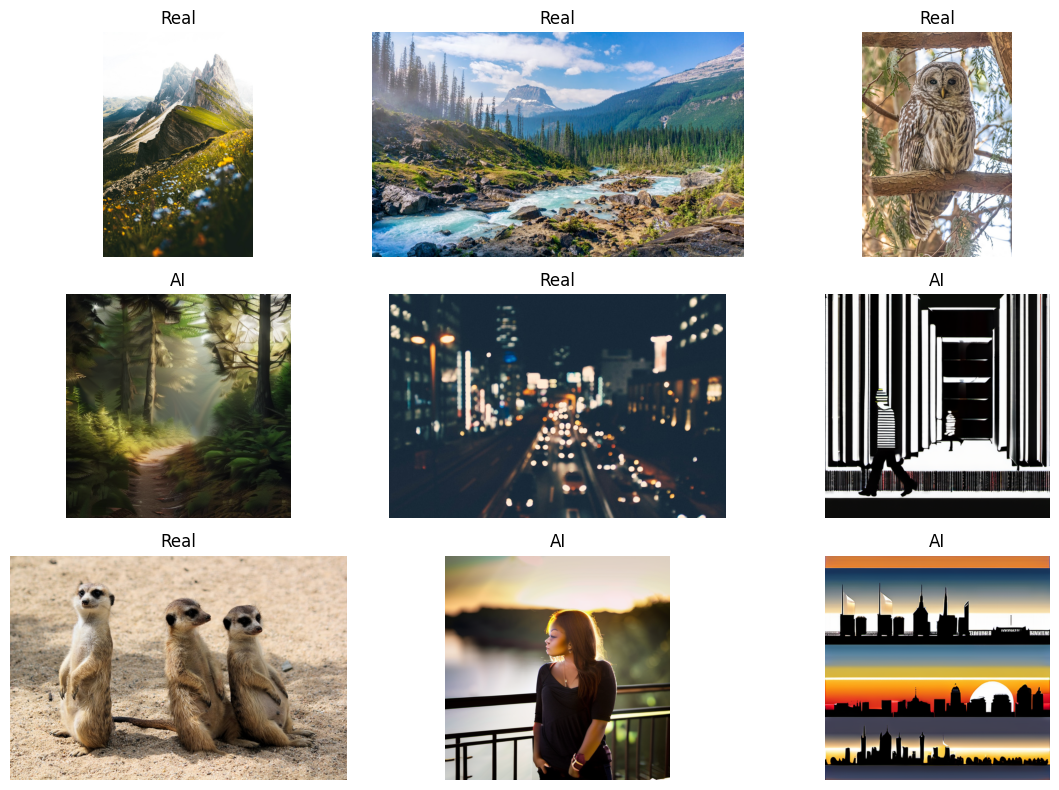

In [ ]:
#Checking whether images are loading correctly
import matplotlib.pyplot as plt
from PIL import Image

plt.figure(figsize=(12, 8))

for i in range(9):
    image_path = train_df.iloc[i]["image_path"]
    label = train_df.iloc[i]["class"]

    image = Image.open(image_path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
print("Complete dataset:")
print(df["class"].value_counts())

Complete dataset:
class
Real    745
AI      250
Name: count, dtype: int64


In [ ]:
# Separate the two classes
real_df = df[df["label"] == 0]
ai_df = df[df["label"] == 1]

# Use the smaller class size
n_samples = min(len(real_df), len(ai_df))

# Randomly select the same number from both classes
real_balanced = real_df.sample(n=n_samples, random_state=42)
ai_balanced = ai_df.sample(n=n_samples, random_state=42)

# Combine them
balanced_df = pd.concat(
    [real_balanced, ai_balanced],
    ignore_index=True
)

# Shuffle
balanced_df = balanced_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("Balanced dataset:")
print(balanced_df["class"].value_counts())
print("Total images:", len(balanced_df))

Balanced dataset:
class
AI      250
Real    250
Name: count, dtype: int64
Total images: 500


In [ ]:
#Training + temporary set
train_df, temp_df = train_test_split(
    balanced_df,
    test_size=0.20,
    stratify=balanced_df["label"],
    random_state=42
)

print("Training:", len(train_df))
print("Temporary:", len(temp_df))

Training: 400
Temporary: 100


In [ ]:
#Validation + testing
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Training images   :", len(train_df))
print("Validation images :", len(val_df))
print("Testing images    :", len(test_df))

Training images   : 400
Validation images : 50
Testing images    : 50


In [ ]:
#Verify the New Split
print("TRAINING")
print(train_df["class"].value_counts())

print("\nVALIDATION")
print(val_df["class"].value_counts())

print("\nTESTING")
print(test_df["class"].value_counts())

TRAINING
class
AI      200
Real    200
Name: count, dtype: int64

VALIDATION
class
Real    25
AI      25
Name: count, dtype: int64

TESTING
class
AI      25
Real    25
Name: count, dtype: int64


In [ ]:
#Set image parameters
IMG_SIZE = 224
BATCH_SIZE = 32

In [ ]:
#creating a function
def load_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image = tf.image.resize(
        image,
        [IMG_SIZE, IMG_SIZE]
    )

    image = tf.cast(image, tf.float32) / 255.0

    return image, label

In [ ]:
#Training dataset
train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        train_df["image_path"].values,
        train_df["label"].values
    )
)

train_dataset = train_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_dataset = train_dataset.shuffle(1000)

train_dataset = train_dataset.batch(BATCH_SIZE)

train_dataset = train_dataset.prefetch(
    tf.data.AUTOTUNE
)

In [ ]:
#Validation dataset
val_dataset = tf.data.Dataset.from_tensor_slices(
    (
        val_df["image_path"].values,
        val_df["label"].values
    )
)

val_dataset = val_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_dataset = val_dataset.batch(BATCH_SIZE)

val_dataset = val_dataset.prefetch(
    tf.data.AUTOTUNE
)

In [ ]:
#Test dataset
test_dataset = tf.data.Dataset.from_tensor_slices(
    (
        test_df["image_path"].values,
        test_df["label"].values
    )
)

test_dataset = test_dataset.map(
    load_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_dataset = test_dataset.batch(BATCH_SIZE)

test_dataset = test_dataset.prefetch(
    tf.data.AUTOTUNE
)

In [ ]:
#Check the Preprocessed Images
images, labels = next(iter(train_dataset))

print("Image shape:", images.shape)
print("Label shape:", labels.shape)

Image shape: (32, 224, 224, 3)
Label shape: (32,)


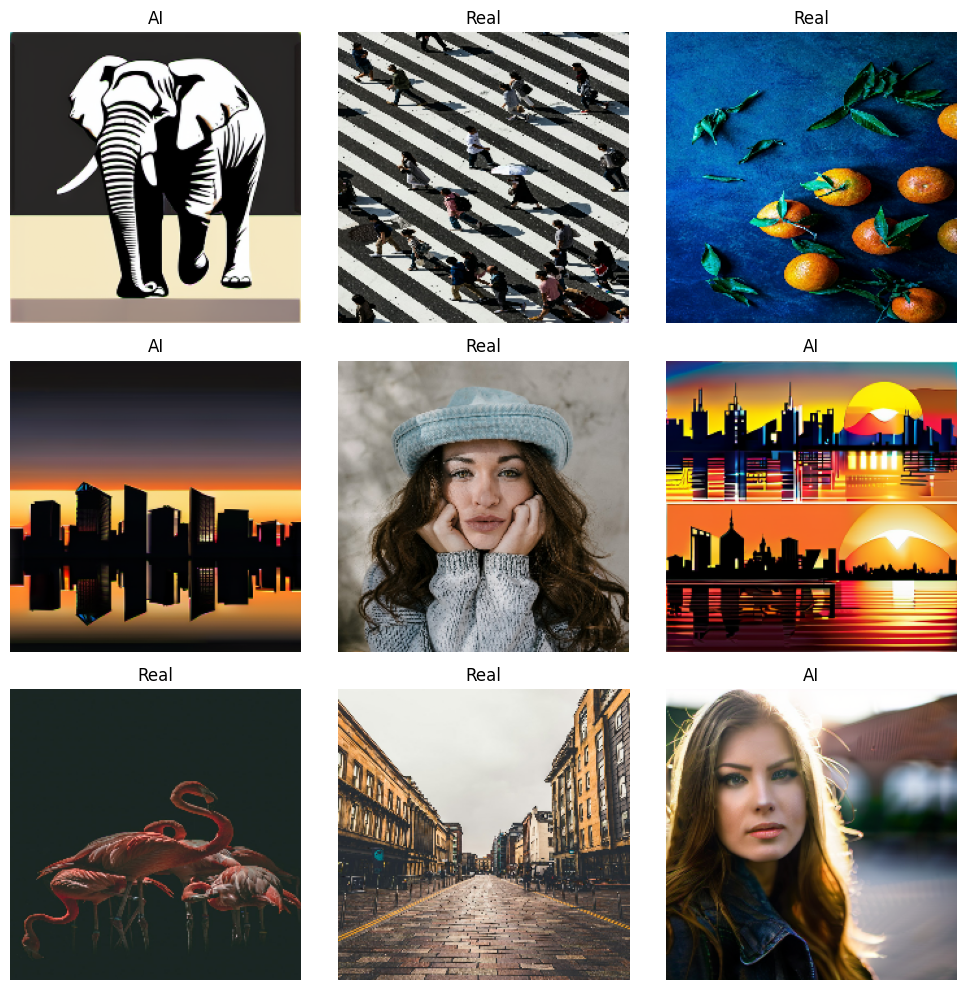

In [ ]:
#Display Preprocessed Images
plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])

    if labels[i].numpy() == 0:
        title = "Real"
    else:
        title = "AI"

    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
#Data Augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [ ]:
model = models.Sequential([

    # Input layer
    layers.Input(shape=(224, 224, 3)),

    # Data Augmentation
    data_augmentation,

    # Convolution Block 1
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Convert feature maps into one-dimensional vector
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation='relu'),

    # Prevent overfitting
    layers.Dropout(0.5),

    # Binary classification output
    layers.Dense(1, activation='sigmoid')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print("GPU Available:")
print(tf.config.list_physical_devices('GPU'))

GPU Available:
[]


In [ ]:
EPOCHS = 10

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS
)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.5450 - loss: 0.7927 - val_accuracy: 0.7400 - val_loss: 0.5661
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - accuracy: 0.7000 - loss: 0.5533 - val_accuracy: 0.7400 - val_loss: 0.5129
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.7725 - loss: 0.4786 - val_accuracy: 0.7200 - val_loss: 0.5583
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.7975 - loss: 0.4377 - val_accuracy: 0.7200 - val_loss: 0.6247
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.7850 - loss: 0.4254 - val_accuracy: 0.6800 - val_loss: 0.6675
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.8225 - loss: 0.3889 - val_accuracy: 0.8000 - val_loss: 0.3777
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.7950 - loss: 0.3939 - val_accuracy: 0.7800 - val_loss: 0.4279
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 30s 2s/step - accuracy: 0.8325 - loss: 0.3470 - val_accuracy: 0.7800 - val_loss:

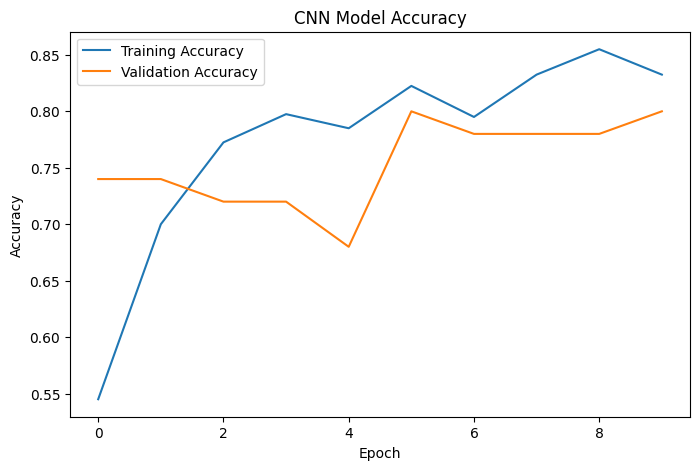

In [ ]:
#Plot Training Accuracy
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('CNN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

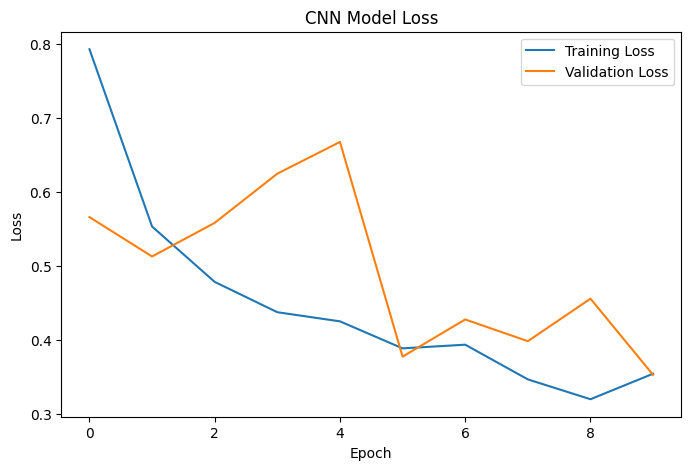

In [ ]:
#Plot Training Loss
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('CNN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [ ]:
#Evaluate on the Test Dataset
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 298ms/step - accuracy: 0.7400 - loss: 0.4751
Test Loss: 0.4750804901123047
Test Accuracy: 0.7400000095367432


In [ ]:
#saving the model
model.save("/content/real_vs_ai_cnn.keras")

print("CNN model saved successfully!")

CNN model saved successfully!


In [ ]:
#Getting Predictions
import numpy as np

y_true = []
y_pred = []

for images, labels in test_dataset:

    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend((predictions > 0.5).astype(int).flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Predictions generated successfully!")

Predictions generated successfully!
